In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import os.path as op

from specula.mmlib.compute_rec import rec_phot_cov, rec_ron_cov
from specula.mmlib.utils import get_pupil_mask, radial_order, compute_modal_variance_von_karman
from specula.mmlib.analyse_data import get_sim_data, get_psd

root_dir = '/raid1/mmenessini/calibration/RISTRETTOunobs'

2026-06-22 17:39:25,464 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-22 17:39:25,587 [INFO]: [specula]: Default device is GPU number 0
2026-06-22 17:39:25,594 [INFO]: [specula]: Cupy import successfull. Installed version is: 14.0.1
2026-06-22 17:39:25,595 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
rMods = np.array([0,1,2,3])
n_subaps = np.array([12,16,24,48]) #np.array([16,24,48])
n_modes = np.array([50,150,300,600,1200]) #np.array([150,300,1300])
seeings = np.array([0.5,0.7,0.9,1.1,1.3,1.5]) #np.array([0.7,0.9,1.1])

In [4]:
def generate_psd(f, cutoff, power):
    f_safe = np.maximum(f, f[0])
    psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
    df = np.gradient(f)
    # f_s = f[-1] * 2 
    # sinc_filter = np.sinc(f_safe / f_s)**2 
    # psd_turb *= sinc_filter
    psd_turb *= (power / np.sum(psd_turb * df))
    return psd_turb

In [ ]:
def get_rec_covariance(rMod,n_subap,seeing,Nphot,RON,N,res:str='',doplot:bool=False):

    pyr_mask = get_pupil_mask(npix=120,filepath=op.join(root_dir,'pupils',f'pyr_pupdata_{n_subap:.0f}x{n_subap:.0f}.fits'))
    frame = fits.getdata(op.join(root_dir,'frames',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_avg_frame.fits'))
    sn = fits.getdata(op.join(root_dir,'slopenulls',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_sn.fits'))+2e-2
    alias = fits.getdata(op.join(root_dir,'aliasing',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes_alias.fits'))
    rec = fits.getdata(op.join(root_dir,'rec',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_{N}modes_rec.fits'))
    simpc = fits.getdata(op.join(root_dir,'im',f'pyr{rMod:1.1f}_{n_subap:.0f}x{n_subap:.0f}_s{seeing:1.2f}_{N}modes{res}_simpc.fits'))

    og = np.diag(rec @ simpc)
    ct = np.sqrt(np.sum((rec @ simpc)**2,axis=0)-og**2)

    ron_cov = rec_ron_cov(rec,frame,mask=pyr_mask)*RON/Nphot**2 
    shot_cov = rec_phot_cov(rec,frame,mask=pyr_mask,sn=sn)/Nphot
    cov = ron_cov + shot_cov

    if doplot:
        x = np.arange(N)+1
        plt.figure()
        plt.loglog(x,ron_cov)
        plt.loglog(x,shot_cov)
        plt.loglog(x,cov)
        plt.grid()

    return cov,og,ct,alias


n_subap = 48
seeing = 1.5
N = 1200
RON = 0.5
Nphot = 1e+6
Nmodes = 1200

res = '_1Nm' #'' #
cov0,og0,ct0,alias0 = get_rec_covariance(rMod=0,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov1,og1,ct1,alias1 = get_rec_covariance(rMod=1,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov2,og2,ct2,alias2 = get_rec_covariance(rMod=2,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)
cov3,og3,ct3,alias3 = get_rec_covariance(rMod=3,n_subap=n_subap,seeing=seeing,Nphot=Nphot,N=Nmodes,RON=RON,res=res)

coverr = lambda cov,alias,og: (cov+alias**2)/og**2

err0 = coverr(cov0,alias0,og0)
err1 = coverr(cov1,alias1,og1)
err2 = coverr(cov2,alias2,og2)
err3 = coverr(cov3,alias3,og3)

x = np.arange(N)+1
plt.figure(figsize=(10,6))
plt.loglog(x,err0,label=r'0 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err0)):1.1f} nm')
plt.loglog(x,err1,label=r'1 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err1)):1.1f} nm')
plt.loglog(x,err2,label=r'2 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err2)):1.1f} nm')
plt.loglog(x,err3,label=r'3 $\lambda/D$'+f', RMS: {np.sqrt(np.sum(err3)):1.1f} nm')
plt.grid(which='both',alpha=0.45)
plt.legend(loc='best',title='$r_{Mod}$')
plt.xlabel(r'KL mode \#')
plt.ylabel('[$nm^2$]')
plt.title(f'{seeing:1.1f}" seeing, {N} modes corrected\n{n_subap}x{n_subap} pyWFS, RON={RON:1.1f}e-, flux={Nphot:1.1e}')

TypeError: get_rec_covariance() missing 1 required positional argument: 'N'

Using data directory: /raid1/mmenessini/results/RISTRETTOunobs/20260621_105343
key: coro_psf_std type: <class 'numpy.ndarray'>
key: sr type: <class 'numpy.ndarray'>
key: coro_psf_int type: <class 'numpy.ndarray'>
key: dm_cmd type: <class 'numpy.ndarray'>
key: atmo_res type: <class 'numpy.ndarray'>
key: pyr_meas type: <class 'numpy.ndarray'>
key: dm_res type: <class 'numpy.ndarray'>
0.815152133671932 4.03027271795837 4.039538 0.8151557


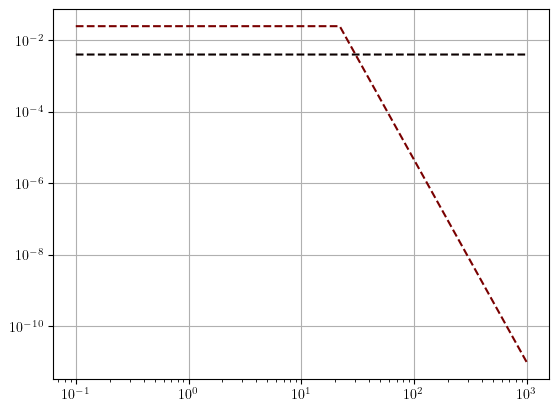

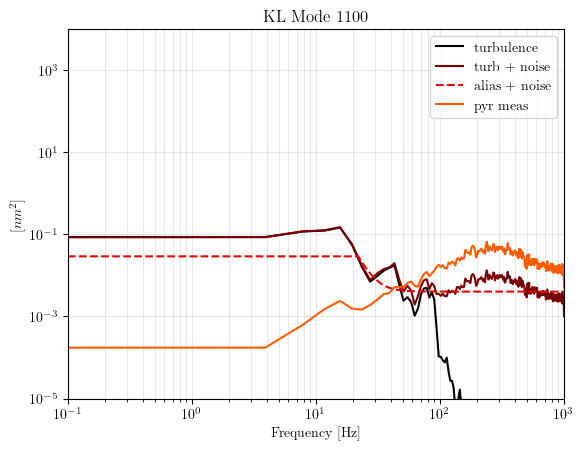

In [15]:
datadict = get_sim_data(root_dir='/raid1/mmenessini/results/RISTRETTOunobs')


VoverD = 12/8.2
cutoff = 0.3*(radial_order(N)+1+1)*VoverD

idx = 1100
ct_amp = 1e-9
ff = np.logspace(-1,3,2000)
alias_psd = generate_psd(ff,cutoff,power=alias0[idx]**2)
noise_psd = np.ones_like(ff)
noise_psd *= (cov0[idx]+ct0[idx]*ct_amp)/(np.sum(noise_psd * np.gradient(ff)))

plt.figure()
plt.loglog(ff,noise_psd,'--')
plt.loglog(ff,alias_psd,'--')
plt.grid()

print(np.sqrt(np.trapezoid(alias_psd,ff)),np.trapezoid(noise_psd,ff),cov0[idx],alias0[idx])

N = 1200
pol = datadict['dm_cmd'][1:] + datadict['pyr_meas'][:-1]
ol = datadict['dm_cmd'] + datadict['dm_res'][:,:N]

init = 100
res_psd,f = get_psd(datadict['dm_res'][init:].T,dt=0.0005,nperseg=512)
pyr_psd,f = get_psd(datadict['pyr_meas'][init:].T,dt=0.0005,nperseg=512)
ol_psd,f = get_psd(ol[init:].T,dt=0.0005,nperseg=512)
pol_psd,f = get_psd(pol[init-1:].T,dt=0.0005,nperseg=512)
atmo_psd,f = get_psd(datadict['atmo_res'][init:].T,dt=0.0005,nperseg=512)

plt.figure()
plt.loglog(f,atmo_psd[idx],label='turbulence')
plt.loglog(f,ol_psd[idx],label='turb + noise')
plt.loglog(ff,noise_psd+alias_psd,'--',label='alias + noise')
# plt.loglog(f,pol_psd[idx])
plt.loglog(f,pyr_psd[idx],label='pyr meas')
# plt.loglog(f,res_psd[idx],label='residual')
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'[$nm^2$]')
plt.title(f'KL Mode {idx}')
plt.ylim([1e-5,1e+4])
plt.xlim([0.1,1e+3])
plt.grid(which='both',alpha=0.3)

In [13]:

from scipy.optimize import minimize

def gen_synth_psd(f, cutoff, n, turb_power, noise_power):
    f_safe = np.maximum(f, f[0])
    if n == 1:
        psd_turb = np.where(f_safe <= cutoff, (f_safe / cutoff)**(-2/3), (f_safe / cutoff)**(-17/3))
    else:
        psd_turb = np.where(f_safe <= cutoff, 1.0, (f_safe / cutoff)**(-17/3))
        
    df = np.gradient(f)
    f_s = f[-1] * 2 
    sinc_filter = np.sinc(f_safe / f_s)**2 
    psd_turb *= sinc_filter
    
    psd_turb *= (turb_power / np.sum(psd_turb * df))
    
    psd_noise = np.ones_like(f)
    psd_noise *= (noise_power / np.sum(psd_noise * df))
    
    return psd_turb, psd_noise

def eval_tf(b, a, f, f_s):
    z_inv = np.exp(-1j * 2 * np.pi * f / f_s)
    num = sum(b[k] * (z_inv**k) for k in range(len(b)))
    den = sum(a[k] * (z_inv**k) for k in range(len(a)))
    return num / den

def is_stable(a):
    roots = np.roots(a)
    return np.all(np.abs(roots) < 0.9999)

def pre_fit_controller(order, f, psd_turb, f_s):
    target_mag = np.sqrt(psd_turb)
    target_mag /= np.max(target_mag)
    
    def loss(params):
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        if not is_stable(a): return 1e6
        C = eval_tf(b, a, f, f_s)
        return np.sum((np.abs(C) - target_mag)**2)

    init_b = np.zeros(order + 1); init_b[0] = 0.1
    init_a = np.zeros(order); init_a[0] = -0.9
    init_params = np.concatenate([init_b, init_a])

    res = minimize(loss, init_params, method='Nelder-Mead', options={'maxiter': 5000})
    b_guess = res.x[:order+1]
    a_guess = np.insert(res.x[order+1:], 0, 1.0)
    return b_guess, a_guess

def cost_function(params, order, f, psd_turb, psd_noise, N, f_s, og=1.0, lambda_reg=1e-3):
    """
    Cost function with L2 Regularization on the numerator coefficients (b)
    to smoothly penalize excessively large gains.
    """
    if order == 0:
        # Simple integrator
        b = np.array([params[0]])
        a = np.array([1.0, -1.0])
    else:
        b = params[:order+1]
        a = np.insert(params[order+1:], 0, 1.0)
        # Keep the boolean penalty for instability, as unstable roots are a hard physical limit
        if not is_stable(a): return 1e9 

    C = eval_tf(b, a, f, f_s)
    P = np.exp(-1j * 2 * np.pi * f * N / f_s)
    H_ol = C * P
    denom = 1.0 + H_ol*og
    
    # # Avoid div by zero if perfectly touching the -1 point
    # if np.min(np.abs(denom)) < 1e-4: return 1e9

    RTF = 1.0 / denom
    NTF = H_ol / denom
    psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * psd_noise)
    
    # Base variance cost
    variance_cost = np.sum(psd_res * np.gradient(f))
    
    # # Smooth L2 Penalty on the numerator magnitude
    # # This prevents the coefficients from exploding to artificially force a fit
    # l2_penalty = lambda_reg * np.sum(b**2)
    
    return variance_cost #+ l2_penalty

def optimize_higher_order_scao(f_s, orders=[0, 1, 2, 3], turb_power=100.0, noise_power=0.5, og=1.0, show:bool=False,
                               delay_steps=2.0, cutoff=15.0, n=1, restarts:int=100, alias_psd=0.0,
                               lambda_reg=1e-3):

    f = np.linspace(0.1, f_s/2.0, 2000)
    psd_turb, psd_noise = gen_synth_psd(f, cutoff, n, turb_power, noise_power)

    rms_ratio = []
    a_coeffs = []
    b_coeffs = []
    
    if show:
        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.loglog(f, psd_turb/psd_noise, label=f'Turbulence PSD (n={n})', c='k')
        plt.loglog(f, psd_noise/psd_noise, ':',label='Noise Floor', c='gray')
        plt.subplot(1, 2, 2)
        plt.loglog(f, psd_turb, label='Uncorrected Turb', c='k')
        plt.loglog(f, psd_noise+alias_psd, ':', label='Noise floor', c='gray')
    

    for i, order in enumerate(orders):
        if order == 0:
            init_params = np.array([0.5])
        else:
            b_guess, a_guess = pre_fit_controller(order, f, psd_turb, f_s)
            init_params = np.concatenate([b_guess, a_guess[1:]])
        
        res = minimize(cost_function, init_params, 
                       args=(order, f, psd_turb, psd_noise+alias_psd, delay_steps, f_s, og, lambda_reg),
                       method='Nelder-Mead', 
                       options={'maxiter': 5000, 'adaptive': True})
        
        if order == 0:
            best_b = np.array([res.x[0]]) if isinstance(res.x, (list, np.ndarray)) else np.array([res.x])
            best_a = np.array([1.0, -1.0])
        else:
            best_b = res.x[:order+1]
            best_a = np.insert(res.x[order+1:], 0, 1.0)
        
        if max(abs(best_b)) < 5e-2: # do not control if gains are too low
            best_b *= 0.0

        C = eval_tf(best_b, best_a, f, f_s)
        P = np.exp(-1j * 2 * np.pi * f * delay_steps / f_s)
        H_ol = C * P
        den = 1.0 + H_ol*og
        RTF = 1.0 / den
        NTF = H_ol / den
        
        # Calculate actual variance without the artificial L2 penalty for accurate reporting
        psd_res = (np.abs(RTF)**2 * psd_turb) + (np.abs(NTF)**2 * (psd_noise+alias_psd))
        min_variance = np.sum(psd_res * np.gradient(f))
        turb_variance = np.sum(psd_turb * np.gradient(f))

        rms_ratio.append(np.sqrt(min_variance))#/turb_variance))
        if order > 0:
            a_coeffs.append(best_a)
            b_coeffs.append(best_b)
        
        if show:
            name = "Integrator" if order == 0 else f"Order {order}"
            print(f"{name}:")
            print(f" B coefficients: {best_b}")
            print(f" A coefficients: {best_a}")
            print(f" Residual Variance: {min_variance:.4e}\n")
            
            plt.subplot(1, 2, 1)
            plt.loglog(f, 1.0/(np.abs(RTF)**2), label=r'$|RTF|^{-2}$'+f' ({name})')
            plt.subplot(1, 2, 2)
            plt.loglog(f, psd_res, label=f'Residual ({name})')

    if show:
        plt.subplot(1, 2, 1)
        plt.title(f"Spectral SNR")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power / Amplitude")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-1,psd_turb[0]/psd_noise[0]*4])
        
        plt.subplot(1, 2, 2)
        plt.title(f"Residual PSD")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Power Spectral Density")
        plt.grid(True, which="both", alpha=0.5)
        plt.legend()
        plt.xlim(f[0], f[-1])
        plt.ylim([1e-1*psd_noise[0],psd_turb[0]*4])

        plt.tight_layout()

    return np.array(rms_ratio), a_coeffs, b_coeffs

In [8]:
seeing = 1.1
r0 = 0.98*500e-9/seeing*180/np.pi*3600
L0 = 25
D = 8.2
kl_inv = fits.getdata(op.join(root_dir,'ifunc','bmc2k_vlt_kl_inv.fits'))
modal_basis = np.linalg.pinv(kl_inv)
pup_mask = fits.getdata('/raid1/mmenessini/calibration/RISTRETTO/pupilstop/vlt_pupil_160pixels.fits')

vkp = compute_modal_variance_von_karman(r0=r0,L0=L0,D=D,modes=modal_basis.T,mask=(1-pup_mask).astype(bool))


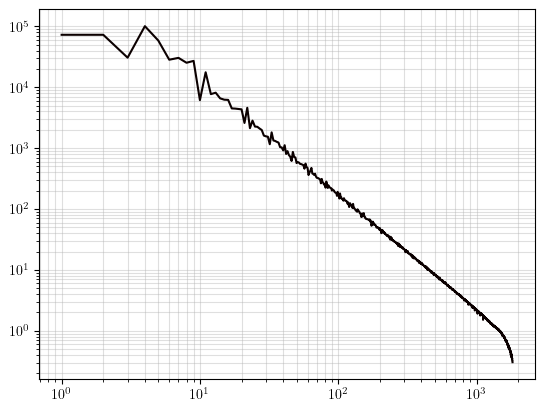

In [9]:

plt.figure()
plt.loglog(np.arange(len(vkp))+1,vkp)
plt.grid(which='both',alpha=0.4)

In [ ]:
idx = 1000
delay = 1.5
VoverD = 20/D
fs = 2000

n_subap = 48
Nphot = 1e+5
RON = 0.5
res = '_1Nm'
N = 1200
cov0,og0,ct0,alias0 = get_rec_covariance(rMod=0,n_subap=n_subap,N=1200,seeing=seeing,Nphot=Nphot,RON=RON,res=res)

orders = [0,1,2,3]
res = np.zeros([len(orders),N])

for idx in range(N):
    res[:,idx],_,_ = optimize_higher_order_scao(f_s=fs,turb_power=vkp[idx],noise_power=cov0[idx],alias_psd=alias_psd,show=True,
                           n=radial_order(idx),cutoff=0.3*(radial_order(idx)+1)*VoverD,delay_steps=delay,og=og0[idx])

Integrator:
 B coefficients: [0.37424316]
 A coefficients: [ 1. -1.]
 Residual Variance: 1.3714e+01

Order 1:
 B coefficients: [0.2646178  0.10794824]
 A coefficients: [ 1.         -0.99989999]
 Residual Variance: 1.3807e+01

Order 2:
 B coefficients: [ 0.44685171 -0.22776236  0.19475677]
 A coefficients: [ 1.         -0.98271104 -0.01718724]
 Residual Variance: 1.2575e+01

Order 3:
 B coefficients: [2.55173455e-05 1.24116717e-01 1.08648902e-01 6.77626240e-02]
 A coefficients: [ 1.         -1.03815359  0.04154375 -0.00329363]
 Residual Variance: 1.6993e+01

Integrator:
 B coefficients: [0.37424316]
 A coefficients: [ 1. -1.]
 Residual Variance: 1.3721e+01

Order 1:
 B coefficients: [0.338065   0.03725672]
 A coefficients: [ 1.     -0.9999]
 Residual Variance: 1.3690e+01

Order 2:
 B coefficients: [ 0.42599442 -0.18093339  0.16549853]
 A coefficients: [ 1.         -0.98433841 -0.01556003]
 Residual Variance: 1.2669e+01

Order 3:
 B coefficients: [2.51943900e-05 1.24166811e-01 1.08671606